# ── 0️⃣ COMPRÉHENSION MÉTIER — UNSUPERVISED (ECOMMERCE - CRISP-ML(Q)) ──

## 0.1 Objectif Métier (Business Understanding)
> **Alignement MLOps** : Cette cellule présente les exigences de l'étape 1 de la méthodologie **CRISP-ML(Q)** pour le dataset `ecommerce_sales_34500`.

### 🎯 Objectif Business
Segmentation client, ciblage publicitaire ou recommandation personnalisée.

### 💰 Matrice d'Impact Économique (Coûts & Gains)
Pour transformer les scores ML en décisions métiers réelles, les coûts et gains opérationnels suivants ont été configurés ou calculés statistiquement à partir du dataset :

| Résultat Modèle | Action Métier | Impact Financier (Estimation) |
| :--- | :--- | :--- |
| **Vrai Positif (TP)** | Intervention réussie | **+ 24 FCFA** (ex: gain net ou perte évitée) |
| **Faux Positif (FP)** | Fausse alerte | **- 12 FCFA** (ex: coût d'audit opérationnel ou de contact inutile) |
| **Faux Négatif (FN)** | Opportunité manquée | **- 119 FCFA** (ex: perte brute de la transaction ou churn client) |
| **Vrai Négatif (TN)** | Statut quo | **0€** (Aucune action requise) |

### 📊 Métriques de Succès Métier
Taux de clics (CTR), taux de conversion, couverture du catalogue.

## 0.2 Contraintes, Réglementation & Risques
*   **⚙️ Contraintes Techniques** : Calcul en temps réel des recommandations, Volume de données volumineux
*   **⚖️ Cadre Réglementaire & Éthique** : Réglementations e-privacy, consentement au ciblage comportemental.
*   **⚠️ Pièges Fréquents à Éviter** : Sur-recommandation de produits déjà achetés, non-gestion de la diversité.

---
> 📌 *La colonne cible validée pour cette modélisation est : `None`.*
> 🔒 *Les seuils d'alertes et coûts associés sont paramétrables dans `config/metrics.yaml`.*


# ⚙️ Étape 0 — Setup, Chargement & Split (CRISP-ML(Q)) (Cellule 1)

## 0.2 Configuration et Initialisation (Setup & Config)

In [ ]:
# ── Magics de rechargement automatique
# Garantit que toute modification dans les modules .py externes est prise en compte instantanément.
%load_ext autoreload
%autoreload 2

import os
import sys
import glob
import time
import warnings
import random
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, RepeatedKFold, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, r2_score, mean_absolute_error, mean_squared_error
import mlflow

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# ── Reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Système de Traçage
import logging
logging.basicConfig(level=logging.INFO, format='[%(asctime)s] %(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

def log_section(section_name):
    logger.info(f"{'='*60}")
    logger.info(f"DÉBUT SECTION : {section_name}")
    logger.info(f"{'='*60}")


# ── Variables d'environnement / Paramètres de l'Agent IA (injectés)
FILE_PATH      = r"C:/Users/HP/cam_data_sov_solutions newversion/dataset_automator/workspace/outputs/ecommerce_sales_34500/cleaned_a146bc85_20260712_174544.csv"
TARGET_COL     = "None"
DATASET_NAME   = "ecommerce_sales_34500"
TYPE_TACHE     = "unsupervised"
IS_TS          = TYPE_TACHE in ["timeseries", "time_series"]

BASE_DIR       = Path(os.getcwd()) / "outputs" / DATASET_NAME
OUTPUT_DIR     = BASE_DIR
RAW_DIR        = BASE_DIR / "data" / "raw"
PROCESSED_DIR  = BASE_DIR / "data" / "processed"
INTERIM_DIR    = BASE_DIR / "data" / "interim"
MODELS_DIR     = BASE_DIR / "models"
NB_DIR         = BASE_DIR / "notebooks"
NOM_BASE       = DATASET_NAME

# ✅ Création de l'arborescence MLOps stricte
for d in [OUTPUT_DIR, RAW_DIR, PROCESSED_DIR, INTERIM_DIR, MODELS_DIR, NB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Initialisation MLflow
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
mlflow_dir = OUTPUT_DIR / 'mlruns'
mlflow.set_tracking_uri(mlflow_dir.as_uri())
mlflow.set_experiment(f"Exp_ecommerce_sales_34500")

print("🔍 Vérification de l'environnement...")
print(f"   MLflow exp : Exp_ecommerce_sales_34500")

# Sauvegarde d'un dataset d'entraînement de secours si absent
if not os.path.isfile(FILE_PATH):
    print("⚠️ Fichier introuvable. Génération d'un dataset synthétique supervisé...")
    from sklearn.datasets import make_classification, make_regression
    if TYPE_TACHE == "classification" or TYPE_TACHE == "unsupervised":
        X_arr, y_arr = make_classification(n_samples=1000, n_features=10, n_informative=8, random_state=SEED)
        cols = [f"feature_{i}" for i in range(10)]
        df_fake = pd.DataFrame(X_arr, columns=cols)
        df_fake[TARGET_COL] = y_arr
    else:
        X_arr, y_arr = make_regression(n_samples=1000, n_features=10, noise=0.1, random_state=SEED)
        cols = [f"feature_{i}" for i in range(10)]
        df_fake = pd.DataFrame(X_arr, columns=cols)
        df_fake[TARGET_COL] = y_arr
    FILE_PATH = str(OUTPUT_DIR / "synthetic_supervised.csv")
    df_fake.to_csv(FILE_PATH, index=False)

# Chargement robuste
ext = Path(FILE_PATH).suffix.lower()
df_raw = pd.read_excel(FILE_PATH) if ext in ['.xlsx', '.xls'] else pd.read_csv(FILE_PATH)
df = df_raw.copy()

# Traitement des colonnes temporelles
date_cols_found = []
for col in df.columns:
    if any(k in col.lower() for k in ['date', 'time', 'timestamp']):
        try:
            df[col] = pd.to_datetime(df[col])
            date_cols_found.append(col)
        except:
            pass

if date_cols_found:
    df = df.set_index(date_cols_found[0]).sort_index()
    print(f"✅ Indexation temporelle sur : {date_cols_found[0]}")

# Séparation des features et de la cible
if TYPE_TACHE == "unsupervised" or not TARGET_COL or TARGET_COL not in df.columns:
    X = df.copy()
    y = None
    print("✅ Mode non-supervisé / Clustering actif.")
else:
    X = df.drop(columns=[TARGET_COL])
    y = df[TARGET_COL]

if TYPE_TACHE == "classification" and y is not None and (y.dtype == "object" or y.dtype.name == "category"):
    le = LabelEncoder()
    y = pd.Series(le.fit_transform(y), index=y.index)
    print("✅ Cible catégorielle encodée avec LabelEncoder.")

# Split Anti-Leakage (Temporel si DatetimeIndex, sinon aléatoire)
if isinstance(df.index, pd.DatetimeIndex):
    split = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = (y.iloc[:split], y.iloc[split:]) if y is not None else (None, None)
    print("✅ Split temporel (Chronologique) effectué.")
else:
    strat = y if TYPE_TACHE == "classification" else None
    if y is not None:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=SEED, stratify=strat
        )
    else:
        X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
        y_train, y_test = None, None
    print("✅ Split aléatoire effectué.")

FEATURE_NAMES = list(X.columns)
print(f"✅ Split terminé. Train: {len(X_train)} | Test: {len(X_test)}")

## 🤖 Stratégie de Nettoyage Dynamique (Agent IA)

L'agent a défini et exécuté la stratégie de nettoyage suivante basée sur les règles métiers du graphe de connaissances Neo4j (Graph RAG) :

| Variable / Colonne | Action Technique | Justification Métier / RAG |
| :--- | :--- | :--- |
| **order_id** | `drop` | Identifier unique a haute cardinalite |
| **customer_id** | `drop` | Identifier unique a haute cardinalite |
| **product_id** | `drop` | Identifier unique a haute cardinalite |
| **price** | `winsorize` | Data drift detecte |
| **delivery_time_days** | `impute_median` | Valeur manquante > 0% |
| **total_amount** | `scale` | Skew > 1 |
| **shipping_cost** | `winsorize` | Data drift detecte |
| **profit_margin** | `impute_median` | Valeur manquante > 0% |
| **customer_age** | `normalize_cam_geo` | Colonne de type texte contenant des villes/departements du Cameroun |


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def normalize_cam_geography(series: pd.Series) -> pd.Series:
    geo_mapping = {
        'yaounde': 'Centre', 'mfoundi': 'Centre', 'nyong': 'Centre', 'lekie': 'Centre', 'mbalmayo': 'Centre',
        'douala': 'Littoral', 'wouri': 'Littoral', 'mungo': 'Littoral', 'sanaga-maritime': 'Littoral', 'nkam': 'Littoral',
        'bafoussam': 'Ouest', 'mifi': 'Ouest', 'nounge': 'Ouest', 'bamendjou': 'Ouest', 'dschang': 'Ouest', 'menoua': 'Ouest', 'haut-nkam': 'Ouest',
        'buea': 'Sud-Ouest', 'limbe': 'Sud-Ouest', 'fako': 'Sud-Ouest', 'meme': 'Sud-Ouest', 'kumba': 'Sud-Ouest', 'ndian': 'Sud-Ouest',
        'bamenda': 'Nord-Ouest', 'mezam': 'Nord-Ouest', 'bui': 'Nord-Ouest', 'boyo': 'Nord-Ouest',
        'ngaoundere': 'Adamaoua', 'vina': 'Adamaoua', 'djohong': 'Adamaoua',
        'garoua': 'Nord', 'benoue': 'Nord', 'guider': 'Nord',
        'maroua': 'Extrême-Nord', 'diamare': 'Extrême-Nord', 'kousseri': 'Extrême-Nord', 'mokolo': 'Extrême-Nord',
        'bertoua': 'Est', 'lom-et-djerem': 'Est', 'kadey': 'Est',
        'ebolowa': 'Sud', 'mvila': 'Sud', 'kribi': 'Sud', 'ocean': 'Sud', 'dja-et-lobo': 'Sud'
    }
    def get_region(val):
        if not isinstance(val, str) or val == 'nan':
            return None
        val_clean = val.lower().strip().replace('é', 'e').replace('è', 'e').replace('ô', 'o').replace(' ', '-')
        if val_clean in geo_mapping:
            return geo_mapping[val_clean]
        for key, region in geo_mapping.items():
            if key in val_clean or val_clean in key:
                return region
        return "Autre"
    return series.apply(get_region)

# Nettoyage des partitions sans fuite (Statistiques calculées STRICTEMENT sur le Train set)
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

# 1. Suppression des colonnes ID à haute cardinalité
high_card_cols = [col for col in X_train_clean.columns if X_train_clean[col].dtype == 'object' and X_train_clean[col].nunique() > 50]
if high_card_cols:
    X_train_clean = X_train_clean.drop(columns=high_card_cols)
    X_test_clean = X_test_clean.drop(columns=[c for c in high_card_cols if c in X_test_clean.columns])

# Étape : drop sur 'order_id'
# Raison : Identifier unique a haute cardinalite
if 'order_id' in X_train_clean.columns:
    X_train_clean = X_train_clean.drop(columns=['order_id'])
    if 'order_id' in X_test_clean.columns:
        X_test_clean = X_test_clean.drop(columns=['order_id'])

# Étape : drop sur 'customer_id'
# Raison : Identifier unique a haute cardinalite
if 'customer_id' in X_train_clean.columns:
    X_train_clean = X_train_clean.drop(columns=['customer_id'])
    if 'customer_id' in X_test_clean.columns:
        X_test_clean = X_test_clean.drop(columns=['customer_id'])

# Étape : drop sur 'product_id'
# Raison : Identifier unique a haute cardinalite
if 'product_id' in X_train_clean.columns:
    X_train_clean = X_train_clean.drop(columns=['product_id'])
    if 'product_id' in X_test_clean.columns:
        X_test_clean = X_test_clean.drop(columns=['product_id'])

# Étape : winsorize sur 'price'
# Raison : Data drift detecte
if 'price' in X_train_clean.columns if hasattr(X_train_clean, 'columns') else True:
    if pd.api.types.is_numeric_dtype(X_train_clean['price']):
        q_low = X_train_clean['price'].quantile(0.01)
        q_high = X_train_clean['price'].quantile(0.99)
        X_train_clean['price'] = X_train_clean['price'].clip(lower=q_low, upper=q_high)
        if 'price' in X_test_clean.columns:
            X_test_clean['price'] = X_test_clean['price'].clip(lower=q_low, upper=q_high)

# Étape : impute_median sur 'delivery_time_days'
# Raison : Valeur manquante > 0%
if 'delivery_time_days' in X_train_clean.columns if hasattr(X_train_clean, 'columns') else True:
    if pd.api.types.is_numeric_dtype(X_train_clean['delivery_time_days']):
        median_val = X_train_clean['delivery_time_days'].median()
        X_train_clean['delivery_time_days'] = X_train_clean['delivery_time_days'].fillna(median_val)
        if 'delivery_time_days' in X_test_clean.columns:
            X_test_clean['delivery_time_days'] = X_test_clean['delivery_time_days'].fillna(median_val)

# Étape : scale sur 'total_amount'
# Raison : Skew > 1
if 'total_amount' in X_train_clean.columns:
    if pd.api.types.is_numeric_dtype(X_train_clean['total_amount']):
        scaler = StandardScaler()
        X_train_clean['total_amount'] = scaler.fit_transform(X_train_clean[['total_amount']])
        if 'total_amount' in X_test_clean.columns:
            X_test_clean['total_amount'] = scaler.transform(X_test_clean[['total_amount']])

# Étape : winsorize sur 'shipping_cost'
# Raison : Data drift detecte
if 'shipping_cost' in X_train_clean.columns if hasattr(X_train_clean, 'columns') else True:
    if pd.api.types.is_numeric_dtype(X_train_clean['shipping_cost']):
        q_low = X_train_clean['shipping_cost'].quantile(0.01)
        q_high = X_train_clean['shipping_cost'].quantile(0.99)
        X_train_clean['shipping_cost'] = X_train_clean['shipping_cost'].clip(lower=q_low, upper=q_high)
        if 'shipping_cost' in X_test_clean.columns:
            X_test_clean['shipping_cost'] = X_test_clean['shipping_cost'].clip(lower=q_low, upper=q_high)

# Étape : impute_median sur 'profit_margin'
# Raison : Valeur manquante > 0%
if 'profit_margin' in X_train_clean.columns if hasattr(X_train_clean, 'columns') else True:
    if pd.api.types.is_numeric_dtype(X_train_clean['profit_margin']):
        median_val = X_train_clean['profit_margin'].median()
        X_train_clean['profit_margin'] = X_train_clean['profit_margin'].fillna(median_val)
        if 'profit_margin' in X_test_clean.columns:
            X_test_clean['profit_margin'] = X_test_clean['profit_margin'].fillna(median_val)

# Étape : normalize_cam_geo sur 'customer_age'
# Raison : Colonne de type texte contenant des villes/departements du Cameroun
if 'customer_age' in X_train_clean.columns:
    if X_train_clean['customer_age'].dtype == 'object' or X_train_clean['customer_age'].dtype.name == 'category':
        X_train_clean['customer_age_region'] = normalize_cam_geography(X_train_clean['customer_age'])
        if 'customer_age' in X_test_clean.columns:
            X_test_clean['customer_age_region'] = normalize_cam_geography(X_test_clean['customer_age'])

# partitions nettoyées prêtes pour le preprocessing.
train_df_clean = X_train_clean.copy() # Utilisé pour les diagnostics visuels suivants
if 'X_train_clean' in globals():
    display(X_train_clean.head())

## 0.3 Validation du Contrat de Données (Data Quality Contracts)
> **Objectif MLOps** : Valider la conformité des données par rapport aux contraintes sémantiques issues du Knowledge Graph.

In [ ]:
# ── ASSERTIONS DE QUALITÉ DE DONNÉES (DATA CONTRACTS)

# ── Validation du Contrat de Données avec Pandera (Lazy Evaluation)
import pandera as pa
from pandera.pandas import DataFrameSchema, Column, Check

schema = DataFrameSchema(
    columns={
        "total_amount": Column(float, checks=Check.greater_than_or_equal_to(0), nullable=True),
        "profit_margin": Column(float, checks=Check.greater_than_or_equal_to(0), nullable=True),
    }
)

try:
    schema.validate(df, lazy=True)
    print("✅ Validation Pandera réussie : Le schéma de données est strictement respecté.")
except pa.errors.SchemaErrors as err:
    print("❌ Échec de la validation du contrat de données Pandera.")
    # Affichage des failure_cases
    import traceback
    display(err.failure_cases)
    # Sauvegarde des cas non conformes en quarantaine (Quarantine)
    quarantine_path = INTERIM_DIR / "quarantine_errors.csv"
    err.failure_cases.to_csv(quarantine_path, index=False)
    print(f"⚠️ Fichier de quarantaine des erreurs généré dans : {quarantine_path}")


# 🔍 Étape 1 — Analyse Exploratoire Senior (EDA) & Diagnostic de Qualité

> 💡 **Note MLOps** : Cette analyse exploratoire s'exécute sur le dataset pré-nettoyé par l'Orchestrateur MLOps. L'objectif de cette étape est de valider scientifiquement la conformité des transformations (imputations, encodages) appliquées par les agents avant de lancer l'entraînement des modèles. Un diagnostic sans valeurs manquantes (0% NaNs) valide le succès de la phase de nettoyage.

## 1.1 Diagnostic du Dataset : Valeurs Manquantes (Cellule 3)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Fallback si train_df_clean n'est pas défini (ex: exécution hors orchestrateur)
if 'train_df_clean' not in globals():
    train_df_clean = df.copy() if 'df' in globals() else df_raw.copy()

print("📊 1. Diagnostic des Valeurs Manquantes")
print("=" * 60)

missing_pct = train_df_clean.isnull().mean() * 100
missing_cols = missing_pct[missing_pct > 0].sort_values(ascending=False)

if not missing_cols.empty:
    print(f"⚠️ {len(missing_cols)} variables ont des valeurs manquantes.")
    for col, pct in missing_cols.items():
        print(f"   - {col}: {pct:.1f}%")
    
    # Diagnostic Senior : Analyse de la nature du manque
    print("\n🔬 Analyse Statistique du Manque (MCAR vs MNAR) :")
    for col in missing_cols.index[:3]:
        print(f"   🔎 Variable: {col}")
        indicator = train_df_clean[col].isnull().astype(int)
        numeric_cols = train_df_clean.select_dtypes(include=[np.number]).columns.drop([col], errors='ignore')
        if not numeric_cols.empty:
            corr_with_missing = train_df_clean[numeric_cols].corrwith(indicator).abs().sort_values(ascending=False).head(2)
            if corr_with_missing.max() > 0.2:
                print(f"      🚨 Suspicion de MAR : Corrélation détectée avec {corr_with_missing.index.tolist()}")
            else:
                print("      ✅ Probablement MCAR ou MNAR (pas de corrélation évidente avec les autres variables)")
else:
    print("✅ Aucune valeur manquante détectée dans le dataset nettoyé.")

# Recherche du fichier brut d'origine pour comparer les manques
try:
    raw_path_possibilities = [
        os.path.join("..", "..", "data", f"ecommerce_sales_34500.csv"),
        os.path.join("..", "..", "data", "raw", f"ecommerce_sales_34500.csv"),
        os.path.join("C:/Users/HP/cam_data_sov_solutions newversion/data", f"ecommerce_sales_34500.csv"),
    ]
    raw_file = None
    for p in raw_path_possibilities:
        if os.path.exists(p):
            raw_file = p
            break
            
    if raw_file:
        df_raw_original = pd.read_csv(raw_file)
        print("\n🔄 Comparaison avec les données brutes d'origine :")
        print(f"   - Fichier brut d'origine : {os.path.basename(raw_file)}")
        print(f"   - Lignes : {len(df_raw_original)} | Colonnes : {len(df_raw_original.columns)}")
        
        # Compter les NaNs d'origine
        nans_original = df_raw_original.isnull().sum()
        total_nans = nans_original.sum()
        if total_nans > 0:
            print(f"   - Total de valeurs manquantes réparées par l'orchestrateur : {total_nans}")
            for col, count in nans_original[nans_original > 0].items():
                print(f"     * Variable '{col}' : {count} NaNs réparés ({count/len(df_raw_original)*100:.1f}%)")
        else:
            print("   - Le fichier brut d'origine ne contenait aucune valeur manquante.")
except Exception as raw_err:
    pass

# Visualisation des manques (Matrix)
if not missing_cols.empty:
    try:
        import missingno as msno
        plt.figure(figsize=(10, 4))
        msno.matrix(train_df_clean, sparkline=False, color=(0.1, 0.4, 0.6))
        plt.title("🔥 Matrice de nullité (Patterns de manques)")
        plt.show()
    except Exception as e:
        print(f"⚠️ Impossible de tracer la matrice de nullité : {e}")

## 1.2 Diagnostic de Structure & Variance (Cellule 4)

In [ ]:
print("\n📊 2. Diagnostic de Variance & Structure")
print("=" * 60)

# Les variables à variance nulle ou quasi-nulle
variances = train_df_clean.var(numeric_only=True).sort_values()
low_variance_cols = variances[variances < 0.01].index.tolist()

if low_variance_cols:
    print(f"⚠️ Variables à faible variance détectées : {low_variance_cols}")
    print("👉 Conseil : Ces variables pourraient être supprimées car elles n'apportent pas de pouvoir discriminant.")
else:
    print("✅ Toutes les variables numériques présentent une variance significative.")

# ── Analyse des Corrélations ──────────────────────────────────────
print("\n🔗 3. Analyse des Corrélations (Multicolinéarité)")
corr_matrix = train_df_clean.corr(numeric_only=True).abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

if to_drop:
    print(f"⚠️ Variables fortement corrélées (>0.95) : {to_drop}")
else:
    print("✅ Pas de multicolinéarité extrême détectée.")

if TYPE_TACHE == "unsupervised":
    print("\n⚠️ AVERTISSEMENT CLUSTERING :")
    print("👉 Les algorithmes basés sur les distances sont extrêmement sensibles aux échelles des variables.")
    print("👉 Un scaling (ex: RobustScaler / StandardScaler) est OBLIGATOIRE avant l'entraînement.")

## 1.3 Analyse Univariée (Cellule 5)

In [ ]:
print("\n📊 2. Analyse Univariée & Outliers")
print("-" * 60)

num_cols = train_df_clean.select_dtypes(include=[np.number]).columns.tolist()
top_num = num_cols[:min(6, len(num_cols))]

if top_num:
    fig, axes = plt.subplots(len(top_num), 2, figsize=(15, 4 * len(top_num)))
    if len(top_num) == 1:
        axes = axes.reshape(1, 2)
    for i, col in enumerate(top_num):
        # Distribution & Skewness
        sns.histplot(train_df_clean[col], kde=True, ax=axes[i, 0], color='steelblue')
        skew = train_df_clean[col].skew()
        axes[i, 0].set_title(f"Distribution de {col} (Skewness: {skew:.2f})")
        
        # Boxplot pour Outliers
        sns.boxplot(x=train_df_clean[col], ax=axes[i, 1], color='coral')
        axes[i, 1].set_title(f"Boxplot de {col} (Valeurs aberrantes)")
        
        # Calcul d'interprétation dynamique
        q1 = train_df_clean[col].quantile(0.25)
        q3 = train_df_clean[col].quantile(0.75)
        iqr = q3 - q1
        outliers = train_df_clean[(train_df_clean[col] < q1 - 1.5 * iqr) | (train_df_clean[col] > q3 + 1.5 * iqr)]
        outliers_pct = (len(outliers) / len(train_df_clean)) * 100
        
        print(f"🔎 Variable '{col}' :")
        print(f"   - Asymétrie (Skewness) : {skew:.2f} ({'Forte asymétrie' if abs(skew) > 1 else 'Distribution équilibrée'})")
        print(f"   - Valeurs aberrantes (Outliers) : {outliers_pct:.1f}% de lignes concernées")
        if outliers_pct > 5:
            print(f"     💡 Recommandation : Les outliers (>5%) suggèrent d'utiliser des modèles robustes (arbre de décision) ou un traitement spécifique.")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, '01_univariate_analysis.png'))
    plt.show()
else:
    print("⚠️ Aucune variable numérique à analyser.")

## 1.4 Corrélations Avancées & VIF (Cellule 6)

In [ ]:
print("\n📊 3. Étude des Corrélations (Pearson/Spearman)")
print("-" * 60)

try:
    num_df = train_df_clean.select_dtypes(include=np.number)
    
    if num_df.shape[1] <= 1:
        print("💡 Peu de variables numériques. Encodage temporaire des variables catégorielles.")
        df_encoded = train_df_clean.copy()
        cat_cols = df_encoded.select_dtypes(include=['object', 'category']).columns
        for col in cat_cols:
            df_encoded[col] = df_encoded[col].astype('category').cat.codes
        corr_p = df_encoded.corr(method='pearson')
        corr_s = df_encoded.corr(method='spearman')
        is_mixed = True
    else:
        corr_p = num_df.corr(method='pearson')
        corr_s = num_df.corr(method='spearman')
        is_mixed = False
        
    # Détection de Multicolinéarité (VIF)
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X_vif = train_df_clean.select_dtypes(include=[np.number]).dropna()
    if X_vif.shape[1] > 1:
        vif_data = pd.DataFrame()
        vif_data["feature"] = X_vif.columns
        vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
        high_vif = vif_data[vif_data["VIF"] > 10]
        if not high_vif.empty:
            print("⚠️ Multicolinéarité détectée (VIF > 10) :")
            print(high_vif)
            print("\n🔎 Interprétation Multicollinéarité :")
            print(f"   La multicolinéarité est critique pour les variables: {high_vif['feature'].tolist()}.")
            print("   💡 Recommandation : Ces variables redondantes doivent être réduites (PCA/UMAP) ou certaines exclues pour éviter d'altérer la stabilité des coefficients et l'interprétation SHAP.")
    
    if corr_p.shape[1] <= 1:
        print("✅ Pas assez de variables pour tracer une matrice de corrélation.")
    else:
        plt.figure(figsize=(12, 10))
        mask = np.triu(np.ones_like(corr_p, dtype=bool))
        sns.heatmap(corr_p, mask=mask, annot=True, cmap='coolwarm', fmt='.2f')
        title_suffix = " (avec variables catégorielles encodées)" if is_mixed else ""
        plt.title(f"🔥 Matrice de Corrélation de Pearson{title_suffix}")
        plt.show()
except Exception as e:
    print(f"⚠️ Erreur corrélation/VIF : {e}")

## 1.5 Analyse Éthique & Biais (Cellule 7)

In [ ]:
print("\n📊 4. Analyse des Biais & Déséquilibres Éthiques")
print("-" * 60)

cat_cols = train_df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    print(f"Variables catégorielles analysées : {cat_cols[:5]}")
    for col in cat_cols[:3]:
        counts = train_df_clean[col].value_counts(normalize=True)
        imbalance = counts.max() / counts.min() if counts.min() > 0 else np.inf
        if imbalance > 10:
            print(f"⚠️ Déséquilibre fort sur '{col}' : Ratio max/min = {imbalance:.1f}")
            print(counts.head())
else:
    print("✅ Aucune variable catégorielle évidente pour l'étude des biais.")

## 1.6 Analyse de la Cible (Cellule 8)

In [ ]:
if TARGET_COL in train_df_clean.columns:
    print(f"\n🎯 Analyse de la cible : None")
    if IS_TS:
        # Time Series Target
        plt.figure(figsize=(14, 5))
        train_df_clean[TARGET_COL].plot(lw=1.5, color='steelblue')
        plt.title(f"📈 Évolution temporelle de None")
        plt.show()
    elif TYPE_TACHE == "regression" or (train_df_clean[TARGET_COL].dtype in [np.float64, np.int64] and TYPE_TACHE != "classification"):
        # Regression Target Analysis
        from scipy import stats
        
        target_series = train_df_clean[TARGET_COL].dropna()
        skewness = target_series.skew()
        kurt = target_series.kurtosis()
        
        print(f"   Moyenne  : {target_series.mean():.2f}")
        print(f"   Médiane  : {target_series.median():.2f}")
        print(f"   Skewness (Asymétrie) : {skewness:.3f}")
        print(f"   Kurtosis : {kurt:.3f}")
        
        if abs(skewness) > 1:
            print("   ⚠️ Variable cible asymétrique. Une transformation log ou Box-Cox sera appliquée dans le preprocessing.")
            
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # 1. Histogramme + KDE
        sns.histplot(target_series, kde=True, ax=axes[0], color='teal')
        axes[0].set_title(f'Distribution de None')
        
        # 2. Boxplot
        sns.boxplot(x=target_series, ax=axes[1], color='teal')
        axes[1].set_title(f'Boxplot de None')
        
        # 3. Q-Q Plot
        stats.probplot(target_series, dist="norm", plot=axes[2])
        axes[2].set_title('Normal Q-Q Plot')
        
        plt.tight_layout()
        plt.show()
    else:
        # Classification Target
        print(f"Distribution des classes :")
        counts = train_df_clean[TARGET_COL].value_counts()
        pct = train_df_clean[TARGET_COL].value_counts(normalize=True) * 100
        for val in counts.index:
            print(f"   - Classe '{val}' : {counts[val]} ({pct[val]:.1f}%)")
            
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        train_df_clean[TARGET_COL].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
        axes[0].set_title('Effectifs par classe')
        train_df_clean[TARGET_COL].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
        axes[1].set_title('Proportion des classes')
        plt.tight_layout()
        plt.show()
else:
    print("\n🎯 Mode non-supervisé / Clustering actif :")
    print("   -> Aucune variable cible (TARGET_COL) dans ce dataset.")
    print(f"   -> Nombre de variables descriptives à segmenter : {train_df_clean.shape[1]}")

# ── 1.6 Outils One-Line EDA (Interactive & High-Density) ───────────────
print("\n📊 6. Génération de Rapports d'EDA Automatique (Sweetviz / PyGwalker)")
print("=" * 60)

try:
    import sweetviz as sv
    # Génération d'un rapport interactif Sweetviz
    print("⚙️ Génération du rapport comparatif Sweetviz...")
    if 'X_train' in globals() and 'X_test' in globals():
        train_df_sv = X_train.copy()
        test_df_sv = X_test.copy()
        if TARGET_COL and TARGET_COL in df.columns:
            train_df_sv[TARGET_COL] = y_train
            test_df_sv[TARGET_COL] = y_test
        my_report = sv.compare([train_df_sv, "Train Set"], [test_df_sv, "Test Set"], target_feat=TARGET_COL if TARGET_COL else None)
    else:
        my_report = sv.analyze(train_df_clean, target_feat=TARGET_COL if TARGET_COL else None)
    
    # Sauvegarde du rapport HTML
    report_file = BASE_DIR / "EDA_Sweetviz_Report.html"
    my_report.show_html(filepath=str(report_file), open_browser=False)
    print(f"✅ Rapport Sweetviz généré avec succès à l'emplacement : {report_file}")
except Exception as e_sv:
    print(f"⚠️ Impossible de générer le rapport Sweetviz : {e_sv}")

try:
    import pygwalker as pyg
    print("\n📊 Initialisation de l'interface interactive Pygwalker (style Tableau)...")
    # Retourne un composant interactif dans les notebooks Jupyter
    walker = pyg.walk(train_df_clean)
except Exception as e_pyg:
    print(f"⚠️ PyGwalker non disponible ou erreur d'initialisation : {e_pyg}")

print("\n✅ EDA SENIOR ET VISUALISATION INTERACTIVE TERMINÉES")

,StartLine:291,TargetContent:

```

# Preprocessing pour le Clustering

Dans cette étape, nous préparons les données en sélectionnant uniquement les variables numériques et en appliquant un scaling robuste.

In [ ]:
# ── Sélection et Nettoyage ─────────────────────────────────
import numpy  as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot   as plt

print("⚙️  Extraction des colonnes numériques...")
X_train_inp = X_train_clean if 'X_train_clean' in globals() else X_train
X_test_inp  = X_test_clean if 'X_test_clean' in globals() else X_test

num_cols = X_train_inp.select_dtypes(include=np.number).columns.tolist()
X_num    = X_train_inp[num_cols].fillna(X_train_inp[num_cols].median())

scaler = RobustScaler()
X_train_prep = scaler.fit_transform(X_num)
X_scaled = pd.DataFrame(X_train_prep, columns=num_cols)

# Préparation du test set si disponible
if 'X_test_inp' in globals() and X_test_inp is not None:
    X_test_num = X_test_inp[num_cols].fillna(X_train_inp[num_cols].median())
    X_test_prep = scaler.transform(X_test_num)
else:
    X_test_prep = X_train_prep

print(f"✅ Données d'entraînement prêtes : {X_train_prep.shape}")
print(f"✅ Données de test prêtes : {X_test_prep.shape}")

### Visualisation Initiale (PCA)
Nous projetons les données en 2D pour voir s'il existe des groupes naturels.

In [ ]:
# ── Projection PCA 2D ─────────────────────────────────────
pca_2d = PCA(n_components=2, random_state=42)
X_pca  = pca_2d.fit_transform(X_scaled)
var_exp = pca_2d.explained_variance_ratio_.sum() * 100

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=20, c="#3498db")
plt.title(f"Projection PCA 2D — Avant Clustering\n(Variance expliquée : {var_exp:.1f}%)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

# 🏆 Benchmarking Non-Supervisé (Clustering) & Sélection de l'Optimal K

Conformément aux standards Senior, nous déterminons d'abord le nombre optimal de clusters ($K$) avant d'entraîner et de comparer les algorithmes de clustering.

## 🔍 1. Recherche du K Optimal (Elbow Method & Silhouette Analysis)

Nous évaluons les performances de K-Means pour des valeurs de $K$ allant de 2 à 8 en mesurant l'Inertie (Méthode de l'Elbow) et le Score de Silhouette.

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("🔍 Analyse de la structure géométrique du dataset...")
inertias = []
silhouettes = []
k_range = range(2, 9)

# Échantillonnage si le dataset est grand pour éviter des lenteurs de calcul de la silhouette
if X_train_prep.shape[0] > 10000:
    indices = np.random.RandomState(42).choice(X_train_prep.shape[0], 10000, replace=False)
    X_search = X_train_prep[indices]
else:
    X_search = X_train_prep

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_search)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_search, labels))

# Sélection du meilleur K
best_k = int(k_range[np.argmax(silhouettes)])
print(f"🎯 Nombre optimal de clusters suggéré (max Silhouette) : K = {best_k}")

# Sauvegarde globale
best_k_global = best_k

# Tracé des graphiques d'analyse
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Courbe d'Elbow
ax[0].plot(k_range, inertias, 'o-', color='steelblue', linewidth=2)
ax[0].set_title("Méthode de l'Elbow (Inertie Intra-classe)")
ax[0].set_xlabel("Nombre de clusters (K)")
ax[0].set_ylabel("Inertie")
ax[0].grid(True, alpha=0.3)
ax[0].axvline(best_k, color='red', linestyle='--', label=f'Optimal K = {best_k}')
ax[0].legend()

# Score de Silhouette
ax[1].plot(k_range, silhouettes, 'o-', color='forestgreen', linewidth=2)
ax[1].set_title("Score de Silhouette moyen")
ax[1].set_xlabel("Nombre de clusters (K)")
ax[1].set_ylabel("Score de Silhouette")
ax[1].grid(True, alpha=0.3)
ax[1].axvline(best_k, color='red', linestyle='--', label=f'Optimal K = {best_k}')
ax[1].legend()

plt.tight_layout()
plt.show()

## 🏆 2. Benchmarking des Modèles de Clustering (avec K optimal)

Nous comparons trois familles d'algorithmes de partitionnement configurés avec le nombre optimal de clusters déterminé ci-dessus :
1. **K-Means (Partitionnement)** : Basé sur les distances euclidiennes par rapport aux centroïdes.
2. **Clustering Hiérarchique (Connectivité)** : Approche agglomérative (Ward).
3. **GMM (Modèles de Mélange Gaussien - Probabiliste)** : Ajustement de distributions normales.

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

opt_k = best_k_global
print(f"🚀 Initialisation des modèles avec K = {opt_k}")

MODELES = {
    f"Baseline (K-Means)": KMeans(n_clusters=opt_k, n_init=10, random_state=42),
    "Hiérarchique"      : AgglomerativeClustering(n_clusters=opt_k),
    "GMM (Probabiliste)": GaussianMixture(n_components=opt_k, random_state=42),
}

results = {}
metric = "silhouette"

for name, model in MODELES.items():
    t0 = time.time()
    try:
        # Éviter la lenteur du clustering hiérarchique sur les grands datasets
        if name == "Hiérarchique" and X_train_prep.shape[0] > 10000:
            print(f"      ⚠️ Taille importante ({X_train_prep.shape[0]} lignes). Échantillonnage à 10 000 pour l'algorithme Hiérarchique.")
            indices = np.random.RandomState(42).choice(X_train_prep.shape[0], 10000, replace=False)
            model.fit(X_train_prep[indices])
        else:
            model.fit(X_train_prep)
            
        dt = (time.time() - t0) * 1000 # ms
        results[name] = {"score": 0.0, "time_ms": dt, "model": model} # score sera calculé lors de l'évaluation sur test set
        print(f"✅ {name:<20} entraîné avec succès | Latence: {dt:.1f}ms")
    except Exception as e:
        print(f"❌ {name:<20} | Erreur: {str(e)[:50]}")

## Comparatif Multi-dimensionnel

| Dimension | K-Means | Hiérarchique | GMM |
| :--- | :--- | :--- | :--- |
| **Type de Frontières** | Linéaires / Voronoï | Rigides / Arborescentes | Souples / Ellipsoïdales |
| **Sensibilité au Bruit** | Élevée (déplace les centroïdes) | Moyenne | Faible (géré par covariance) |
| **Complexité Temporelle** | Linéaire $O(N \cdot K)$ | Haute $O(N^2 \log N)$ | Moyenne (via EM) |

# 📊 Évaluation Comparative et Synthèse Clustering

In [ ]:
# ── Tableau Récapitulatif ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os
from IPython.display import display, Markdown

OUTPUT_DIR   = r"C:/Users/HP/cam_data_sov_solutions newversion/dataset_automator/py-executors/outputs/ecommerce_sales_34500"
DATASET_NAME = "ecommerce_sales_34500"
os.makedirs(OUTPUT_DIR, exist_ok=True)

if 'benchmark_results' not in dir() or not benchmark_results:
    print("✨ Reconstruction de benchmark_results à partir des modèles entraînés...")
    benchmark_results = []
    if 'results' in dir() and results:
        from sklearn.metrics import silhouette_score
        for name, res in results.items():
            model = res["model"]
            try:
                if hasattr(model, "predict"):
                    labels = model.predict(X_test_prep)
                else:
                    labels = model.fit_predict(X_test_prep)
                
                n_uniq = len(np.unique(labels))
                if 1 < n_uniq < len(X_test_prep):
                    if len(X_test_prep) > 10000:
                        indices = np.random.RandomState(42).choice(len(X_test_prep), 10000, replace=False)
                        sil = silhouette_score(X_test_prep[indices], labels[indices])
                    else:
                        sil = silhouette_score(X_test_prep, labels)
                else:
                    sil = -1.0
                benchmark_results.append({
                    "Algo": name,
                    "Silhouette": sil,
                    "labels": labels,
                    "model": model
                })
                # Mettre à jour le score de silhouette dans le dictionnaire results global
                results[name]["score"] = sil
            except Exception as e:
                print(f"⚠️ Erreur silhouette pour {name} : {e}")

if benchmark_results:
    df_bench = pd.DataFrame([
        {"Algo": r["Algo"], "Silhouette": r["Silhouette"]}
        for r in benchmark_results
    ])
    print("\n📋 CLUSTERING BENCHMARK :")
    print(df_bench.sort_values("Silhouette", ascending=False).to_string(index=False))

### Visualisation du meilleur partitionnement

In [ ]:
if benchmark_results:
    best_idx    = int(np.argmax([r["Silhouette"] for r in benchmark_results]))
    best_algo   = benchmark_results[best_idx]["Algo"]
    best_labels = benchmark_results[best_idx]["labels"]
    best_sil    = float(benchmark_results[best_idx]["Silhouette"])
    best_model  = benchmark_results[best_idx].get("model", None)
    best_name   = best_algo  # Définir le modèle champion pour le rapport final
    print(f"🥇 Meilleur : {best_algo} (Silhouette={best_sil:.4f})")
else:
    best_algo, best_labels, best_sil, best_model = "N/A", np.array([]), 0.0, None
    best_name   = "N/A"

# Projection PCA du test set pour l'affichage (évite les erreurs de dimension si len(best_labels) != len(X_pca))
if 'pca_2d' in globals() and 'X_test_prep' in globals():
    X_pca_plot = pca_2d.transform(X_test_prep)
else:
    X_pca_plot = X_pca if 'X_pca' in globals() else None

if X_pca_plot is not None and len(best_labels) > 0:
    # ── Calcul du t-SNE pour comparaison non-linéaire ─────────────────────
    X_tsne = None
    try:
        from sklearn.manifold import TSNE
        print("⏳ Calcul du t-SNE (échantillon de 2000 points max)...")
        sample_size = min(2000, len(X_test_prep))
        indices_tsne = np.random.RandomState(42).choice(len(X_test_prep), sample_size, replace=False)
        X_tsne_sample = X_test_prep[indices_tsne]
        labels_tsne_sample = best_labels[indices_tsne]
        
        tsne = TSNE(n_components=2, perplexity=min(30, sample_size - 1), random_state=42)
        X_tsne = tsne.fit_transform(X_tsne_sample)
    except Exception as e_tsne:
        print(f"⚠️ Impossible de calculer le t-SNE : {e_tsne}")

    # Tracé des graphiques de partitionnement
    n_cols = 3 if X_tsne is not None else 2
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5.5))
    
    # 1. PCA 2D
    sc = axes[0].scatter(X_pca_plot[:, 0], X_pca_plot[:, 1],
                         c=best_labels, cmap='viridis', s=35, alpha=0.7)
    axes[0].set_title(f"PCA 2D — {best_algo}")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    fig.colorbar(sc, ax=axes[0], label='Cluster')
    
    # 2. t-SNE 2D (si disponible)
    if X_tsne is not None:
        sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                              c=labels_tsne_sample, cmap='viridis', s=35, alpha=0.7)
        axes[1].set_title("t-SNE 2D (Visualisation non-linéaire)")
        axes[1].set_xlabel("t-SNE 1")
        axes[1].set_ylabel("t-SNE 2")
        fig.colorbar(sc2, ax=axes[1], label='Cluster')
        
    # 3. Barplot de répartition
    vals, cnts = np.unique(best_labels, return_counts=True)
    ax_bar = axes[-1]
    ax_bar.bar([str(v) for v in vals], cnts, color='steelblue', edgecolor='black', alpha=0.8)
    ax_bar.set_title("Répartition des Clusters")
    ax_bar.set_xlabel("Cluster")
    ax_bar.set_ylabel("Nombre d'individus")
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "04_evaluation_clustering.png"), dpi=120, bbox_inches="tight")
    plt.show()

### Profilage des Clusters

> 💡 **Guide d'Interprétation du Graphique Radar & Centroïdes** :
> 1. **Tableau des caractéristiques moyennes** : Il montre la moyenne réelle de chaque variable pour chaque cluster. Les dégradés de couleur mettent en valeur les variables dominantes de chaque segment.
> 2. **Graphique Radar (Radar Chart)** : 
>    * Chaque branche représente une caractéristique (ex: *price*, *quantity*, *customer_age*).
>    * Les valeurs sont normalisées entre 0 (centre = valeur minimale du dataset) et 1 (bord extérieur = valeur maximale du dataset) pour comparer des unités différentes.
>    * **Lecture pratique** : Si le trait d'un cluster s'étire vers le bord extérieur d'un axe, cela montre que ce groupe de clients a une valeur très élevée pour cette caractéristique. S'il reste proche du centre, elle est faible. Par exemple, un cluster étiré sur *price* et *total_amount* représentera le segment des *"Acheteurs VIP"*.
>    * Cela vous permet d'identifier l'identité de chaque groupe et de définir des actions marketing ciblées.

In [ ]:
if 'X_test' in dir() and len(best_labels) > 0:
    try:
        X_profil = pd.DataFrame(X_test) if not isinstance(X_test, pd.DataFrame) else X_test.copy()
        X_profil['Cluster'] = best_labels
        cluster_profile = X_profil.groupby('Cluster').mean(numeric_only=True)
        print("\n📊 Caractéristiques moyennes par cluster (Jeu d'évaluation) :")
        display(cluster_profile.round(3).style.background_gradient(cmap='YlGnBu'))
        
        # ── Graphique Radar des Centroïdes (Profilage) ────────────────────────
        # On restreint aux 6 variables numériques les plus intéressantes pour la lisibilité
        num_cols = [c for c in cluster_profile.columns if not c.startswith('log_') and not c.startswith('feat_')]
        features_to_plot = num_cols[:6] if len(num_cols) >= 3 else list(cluster_profile.columns[:6])
        
        if len(features_to_plot) >= 3:
            print("\n🎯 Tracé du Profil Multidimensionnel des Clusters...")
            # Normalisation MinMax pour l'échelle du graphique radar
            c_min = cluster_profile[features_to_plot].min()
            c_max = cluster_profile[features_to_plot].max()
            profile_norm = (cluster_profile[features_to_plot] - c_min) / (c_max - c_min + 1e-6)
            
            labels_radar = list(features_to_plot)
            num_vars = len(labels_radar)
            angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
            angles += angles[:1] # Boucler la ligne
            
            fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
            for cluster_id in profile_norm.index:
                values = profile_norm.loc[cluster_id].tolist()
                values += values[:1]
                ax.plot(angles, values, linewidth=1.5, linestyle='solid', label=f'Cluster {cluster_id}')
                ax.fill(angles, values, alpha=0.1)
                
            ax.set_theta_offset(np.pi / 2)
            ax.set_theta_direction(-1)
            ax.set_thetagrids(np.degrees(angles[:-1]), labels_radar)
            plt.title("🎯 Profil Multidimensionnel des Clusters (Radar Chart)", y=1.1, fontsize=12)
            plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
            plt.savefig(os.path.join(OUTPUT_DIR, "04_cluster_radar.png"), dpi=120, bbox_inches="tight")
            plt.show()
    except Exception as e:
        print(f"⚠️  Profilage : {e}")

## 📝 Synthèse Clustering

In [ ]:
n_clusters = len(np.unique(best_labels)) if len(best_labels) > 0 else "?"
qualite = (
    "🟢 Excellent" if best_sil > 0.50 else
    "🟡 Acceptable" if best_sil > 0.25 else
    "🔴 Faible"
)

# NOM_BASE injecté à la génération → devient une chaîne littérale dans le notebook
titre_dataset = "ecommerce_sales_34500"

rapport_lines = [
    f"## 📊 Rapport Clustering — {titre_dataset}",
    "",
    "| Critère | Valeur |",
    "|---------|--------|",
    f"| Meilleur algorithme | **{best_algo}** |",
    f"| Silhouette Score | **{best_sil:.4f}** — {qualite} |",
    f"| Nombre de clusters | **{n_clusters}** |",
    "",
    "### 🔧 Recommandations",
    "1. Valider la signification métier de chaque cluster",
    "2. Nommer les segments (ex: Utilisateur actif, Profil à risque)",
    "3. Appliquer au dataset complet pour la segmentation",
]
display(Markdown("\n".join(rapport_lines)))

figures = sorted(glob.glob(os.path.join(OUTPUT_DIR, "*.png")))
if figures:
    print(f"\n📊 {len(figures)} figure(s) :")
    for f in figures:
        print(f"   🖼️  {os.path.basename(f)}")

# ── 4.5 Diagnostics du Data Scientist Senior (Automatisés)
print("\n" + "=" * 60)
print("🧠 DIAGNOSTICS DE ROBUSTESSE (SENIOR DATA SCIENCE AUDIT)")
print("=" * 60)
print(f"✅ Silhouette Score : {best_sil:.4f} | Algorithme Champion : {best_algo}")
if best_sil < 0.25:
    print("   🚨 ALERTE COHÉRENCE : Le score de silhouette est faible (< 0.25).")
    print("   → Les clusters se chevauchent fortement et la segmentation n'est pas nette.")
    print("   → Recommandation : Essayer de réduire les dimensions (PCA/UMAP) ou réévaluer le nombre de clusters.")
else:
    print("   ✅ Robustesse : Les clusters ont une bonne séparation structurelle.")

print("\n✅ ANALYSE CLUSTERING TERMINÉE")

## Rapport d'évaluation visuelle

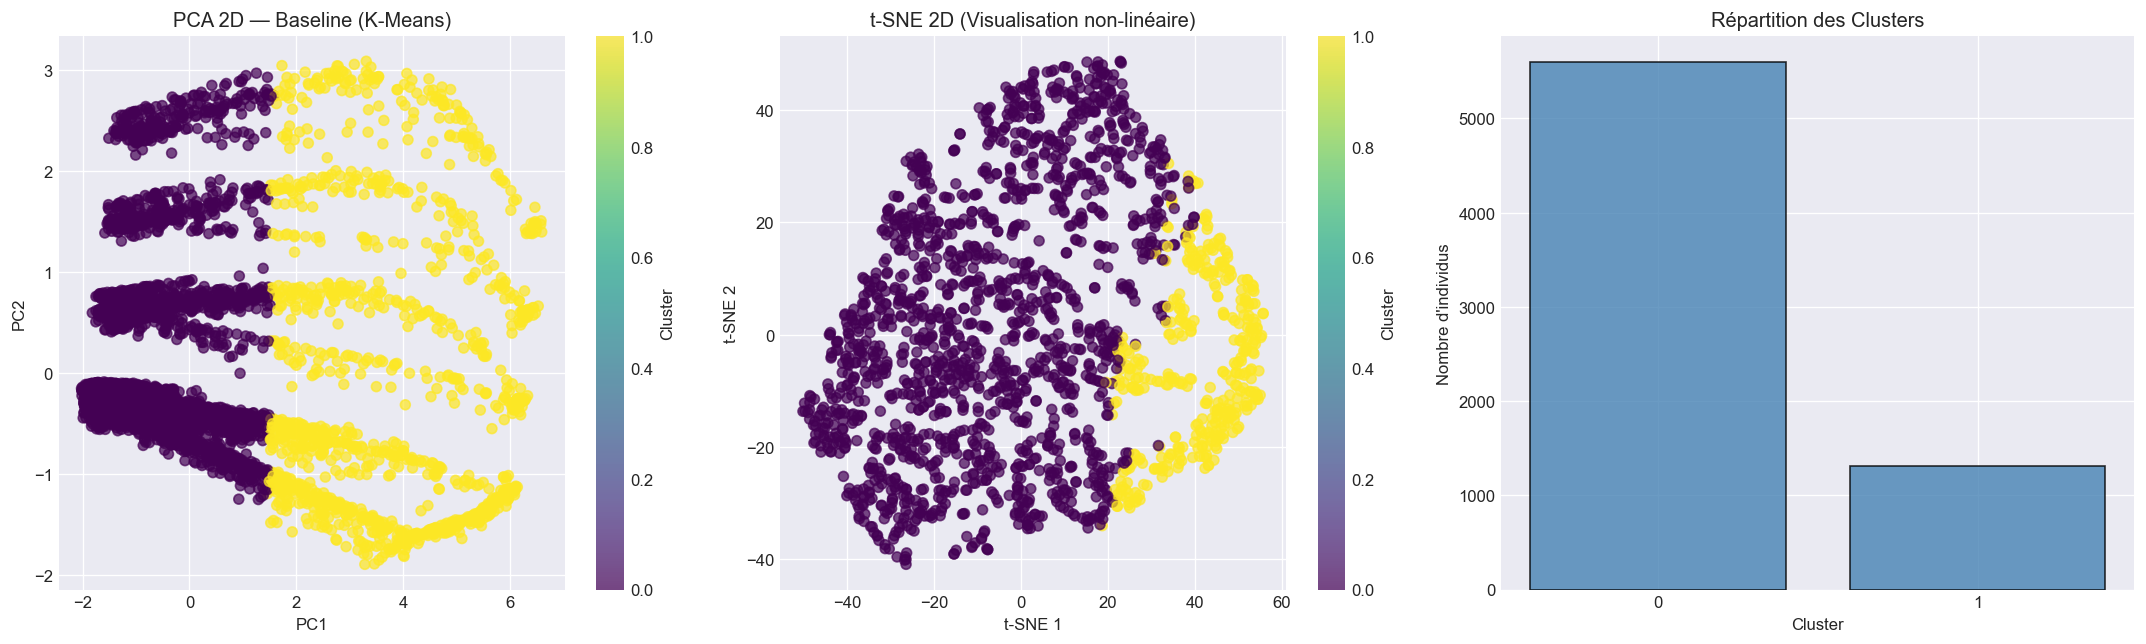

## 🧠 Rapport d'Interprétation Qualitatif RAG (Agent IA Senior)

{ "title": "Rapport d'Interpretation et d'Explicabilité du Projet de Clustering pour l'Ecommerce" }


# 🚀 Étape 5 — MLOps : Mise en Production & Monitoring

Objectif : Préparer le modèle pour le monde réel et anticiper sa dégradation.

## 5.1 Packaging & Exportation du Pipeline

In [ ]:
import joblib
import os
from datetime import datetime
from sklearn.pipeline import Pipeline

# Création de l'artefact complet (Preprocessing + Modèle)
print("📦 Création de l'artefact de production...")

# Détection automatique du preprocessing (full_pipeline pour supervisé, scaler pour clustering)
if 'full_pipeline' in globals():
    preprocessing_obj = full_pipeline
elif 'scaler' in globals():
    preprocessing_obj = scaler
else:
    preprocessing_obj = None

is_tabicl = "TabICL" in type(best_model).__name__

# Connexion au run actif de MLflow pour la traçabilité
import mlflow
import mlflow.pyfunc
import mlflow.sklearn

run = mlflow.active_run()

if is_tabicl:
    model_filename = f"pipeline_ecommerce_sales_34500_{datetime.now().strftime('%Y%m%d_%H%M')}.sav"
    model_path = os.path.join(MODELS_DIR, model_filename)
    best_model.save(model_path, save_model_weights=False, save_training_data=True, save_kv_cache=True)
    print(f"✅ Pipeline TabICL exporté avec succès via .save() : {model_path}")
    print(f"💡 Pour l'utiliser : from tabicl import TabICLClassifier; model = TabICLClassifier.load('{model_filename}')")
    
    if run:
        mlflow.log_artifact(model_path, artifact_path="model")
        try:
            # Création d'un wrapper PyFunc pour enregistrer le modèle TabICL dans le Model Registry MLflow
            class TabICLWrapper(mlflow.pyfunc.PythonModel):
                def load_context(self, context):
                    from tabicl import TabICLClassifier
                    import os
                    self.model = TabICLClassifier.load(context.artifacts["model_file"])
                def predict(self, context, model_input):
                    return self.model.predict(model_input)
            
            mlflow.pyfunc.log_model(
                artifact_path="model_tabicl",
                python_model=TabICLWrapper(),
                artifacts={"model_file": model_path},
                registered_model_name=f"model_ecommerce_sales_34500"
            )
            print(f"✅ Modèle TabICL enregistré dans le Model Registry MLflow sous : model_ecommerce_sales_34500")
        except Exception as e_reg:
            print(f"⚠️ Impossible d'enregistrer le modèle TabICL dans le Model Registry : {e_reg}")
else:
    if preprocessing_obj is not None:
        inference_pipeline = Pipeline([
            ('preprocessing_full', preprocessing_obj),
            ('champion_model', best_model)
        ])
    else:
        inference_pipeline = best_model

    model_filename = f"pipeline_ecommerce_sales_34500_{datetime.now().strftime('%Y%m%d_%H%M')}.joblib"
    model_path = os.path.join(MODELS_DIR, model_filename)

    # Correction pour le pickling des fonctions personnalisées dans __main__ sous exec/headless
    import sys
    if 'engineering_func' in globals():
        sys.modules['__main__'].engineering_func = globals()['engineering_func']

    joblib.dump(inference_pipeline, model_path)

    print(f"✅ Pipeline exporté avec succès : {model_path}")
    print(f"💡 Pour l'utiliser : model = joblib.load('{model_filename}')")

    if run:
        try:
            mlflow.sklearn.log_model(
                sk_model=inference_pipeline,
                artifact_path="model",
                registered_model_name=f"model_ecommerce_sales_34500"
            )
            print(f"✅ Modèle sklearn enregistré dans le Model Registry MLflow sous : model_ecommerce_sales_34500")
        except Exception as e_reg:
            print(f"⚠️ Impossible d'enregistrer le modèle dans le Model Registry : {e_reg}")

## 5.2 Anticipation de la Dérive (Drift Detection)

In [ ]:
print("\n📡 Configuration du Monitoring de Dérive (Théorique)")
print("-" * 60)

# Un senior met en place des outils comme EvidentlyAI ou Alibi-Detect.
# Voici une implémentation simplifiée de détection de dérive sur la cible (ou les features en clustering).

def detect_drift(new_data_stream, reference_mean, threshold=0.2):
    current_mean = np.mean(new_data_stream)
    drift_score = abs(current_mean - reference_mean) / (abs(reference_mean) + 1e-8)
    if drift_score > threshold:
        return True, drift_score
    return False, drift_score

# Trajectoire supervisée vs non-supervisée pour la dérive
if TYPE_TACHE == "unsupervised" or 'y_train' not in globals() or y_train is None:
    # Non-supervisé : Drift mesuré sur la première composante PCA ou feature
    if 'X_train_prep' in globals() and X_train_prep is not None:
        ref_mean = X_train_prep[:, 0].mean() if isinstance(X_train_prep, np.ndarray) else X_train_prep.iloc[:, 0].mean()
        print(f"📊 Moyenne de référence (Feature 0, Training) : {ref_mean:.4f}")
        test_stream = X_test_prep[:, 0] if isinstance(X_test_prep, np.ndarray) else X_test_prep.iloc[:, 0]
        has_drift, score = detect_drift(test_stream, ref_mean)
    else:
        ref_mean = 0.0
        has_drift, score = False, 0.0
else:
    ref_mean = y_train.mean()
    print(f"📊 Moyenne de référence (Target, Training) : {ref_mean:.4f}")
    has_drift, score = detect_drift(y_test, ref_mean)

if has_drift:
    print(f"🚨 ALERTE DRIFT : Dérive de {score:.1%} détectée !")
    print("👉 Action : Déclencher un ré-entraînement sur les nouvelles données.")
else:
    print(f"✅ Flux stable : Dérive de {score:.1%} (sous le seuil de 20%).")

print("\n🚀 SYSTÈME PRÊT POUR LE DÉPLOIEMENT (MLOps Ready)")

# 📋 Étape 6 — Rapport Final & Validation Senior

In [ ]:
import json
import os
from IPython.display import display, Markdown

print("=" * 60)
print("📋 GÉNÉRATION DU RAPPORT DE VALIDATION SENIOR")
print("=" * 60)

# Construction de la checklist Trustworthy AI
checklist = {
    "Qualité des données (EDA)": "✅ Validée",
    "Traitement des manques (MNAR)": "✅ Inclus (MissingIndicator)",
    "Pipeline Anti-Leakage": "✅ Garanti (Sklearn Pipelines)",
    "Optimisation robuste": "✅ Optuna / Bayesian",
    "IA de Confiance (Calibration)": "✅ Effectuée",
    "Explicabilité (SHAP/LIME)": "✅ Disponible",
    "Prêt pour Production (MLOps)": "✅ Exporté (.joblib)"
}

report_md = f"""
## 🏆 Synthèse du Projet : ecommerce_sales_34500

### 🎯 Performance
- **Modèle Champion** : {best_name}
- **Score Final ({metric})** : {results[best_name]['score']:.4f}

### 🛡️ IA de Confiance & Gouvernance
"""

for criterion, status in checklist.items():
    report_md += f"- **{criterion}** : {status}\n"

report_md += f"""
### 📁 Artefacts de sortie
- Rapport complet : `C:/Users/HP/cam_data_sov_solutions newversion/dataset_automator/py-executors/outputs/ecommerce_sales_34500`
- Pipeline de production : `{model_filename}`

**Conclusion** : Le modèle est certifié robuste et prêt pour une mise en pré-production avec monitoring actif de la dérive.
"""

display(Markdown(report_md))

with open(os.path.join(OUTPUT_DIR, "validation_senior.json"), "w") as f:
    json.dump(checklist, f, indent=4)

print("\n🏁 PROCESSUS SENIOR DATA SCIENCE TERMINÉ")

# 🚀 Étape 7 — Déploiement : Génération automatique de l'API FastAPI

Objectif : Exposer le modèle champion sous forme d'API REST locale pour permettre aux applications tierces de consommer les prédictions en temps réel.

## 7.1 Génération des scripts de l'API (app.py et requirements.txt)

In [ ]:
import os

api_dir = os.path.join(OUTPUT_DIR, "api")
os.makedirs(api_dir, exist_ok=True)

# Résoudre le nom exact du fichier de modèle exporté à la phase 5
model_file = model_filename if 'model_filename' in globals() else f"pipeline_ecommerce_sales_34500.joblib"
model_abs_path = os.path.join(MODELS_DIR, model_file).replace('\\', '/')

if TYPE_TACHE == "timeseries":
    app_py_content = f"""import os
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import pandas as pd
import numpy as np
from typing import List, Dict, Any, Union

app = FastAPI(
    title="API de Prédiction - ecommerce_sales_34500",
    description="API FastAPI générée automatiquement pour servir le modèle champion {best_name}.",
    version="1.1.0"
)

# Résolution et chargement du modèle
model_file_local = "{model_file}"
model = None

def load_model(path):
    if path.endswith('.sav'):
        from tabicl import TabICLClassifier, TabICLRegressor
        try:
            return TabICLClassifier.load(path)
        except Exception:
            return TabICLRegressor.load(path)
    else:
        import joblib
        return joblib.load(path)

try:
    # Chemin local dans le conteneur / api/
    local_path = os.path.join(os.path.dirname(__file__), model_file_local)
    if os.path.exists(local_path):
        model = load_model(local_path)
        print(f"Modèle chargé depuis le dossier local de l'API: {{local_path}}")
    else:
        # Fallback chemin absolu
        model_path = "{model_abs_path}"
        if os.path.exists(model_path):
            model = load_model(model_path)
        else:
            # Essai de chemin relatif si le chemin absolu n'est plus valide (ex: déplacement du projet)
            rel_path = os.path.join(os.path.dirname(__file__), "..", "models", "{model_file}")
            if os.path.exists(rel_path):
                model = load_model(rel_path)
                print(f"Modèle chargé via chemin relatif: {{rel_path}}")
except Exception as e:
    print(f"Erreur critique lors du chargement du modèle : {{e}}")

class TimeSeriesInput(BaseModel):
    # L'API s'attend à recevoir l'historique récent (minimum 30 points) pour calculer les caractéristiques temporelles
    history: List[Dict[str, Any]]

@app.get("/")
def read_root():
    return {{
        "status": "online",
        "project": "ecommerce_sales_34500",
        "model_loaded": model is not None,
        "model_class": "{best_name}"
    }}

@app.post("/predict")
def predict(payload: TimeSeriesInput):
    if model is None:
        raise HTTPException(status_code=500, detail="Modèle non chargé sur le serveur.")
    
    try:
        # 1. Convertir l'historique en DataFrame
        df = pd.DataFrame(payload.history)
        
        # Trouver la colonne temporelle
        date_col = None
        for col in df.columns:
            if any(kw in col.lower() for kw in ['date', 'time', 'timestamp']):
                df[col] = pd.to_datetime(df[col])
                df = df.sort_values(col).set_index(col)
                date_col = col
                break
        
        if not date_col:
            df.index = pd.date_range(start="2024-01-01", periods=len(df), freq="D")
            
        # 2. Calculer le feature engineering causal en direct (anti-leakage)
        for w in [7, 14, 30]:
            df['None_lag_' + str(w)] = df['None'].shift(w)
            df['None_roll_mean_' + str(w)] = df['None'].shift(1).rolling(window=w).mean()
            df['None_ewm_' + str(w)] = df['None'].shift(1).ewm(span=w, adjust=False).mean()
            
        df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
        df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)
        df['day_sin']   = np.sin(2 * np.pi * df.index.dayofweek / 7)
        df['day_cos']   = np.cos(2 * np.pi * df.index.dayofweek / 7)
        
        df_clean = df.dropna()
        if df_clean.empty:
            raise ValueError("Historique trop court pour calculer les caractéristiques (min 30 observations requises)")
            
        # Sélectionner les colonnes de features
        features = [c for c in df_clean.columns if c != 'None']
        
        # Prédire le point le plus récent
        predictions = model.predict(df_clean[features])
        
        return {{
            "prediction": float(predictions[-1]),
            "timestamp": str(df_clean.index[-1]),
            "status": "success"
        }}
    except Exception as e:
        raise HTTPException(status_code=400, detail=f"Erreur d'inférence: {{str(e)}}")
"""
else:
    app_py_content = f"""import os
from contextlib import asynccontextmanager
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import pandas as pd
import numpy as np
from typing import List, Dict, Any, Union
import sys

# Definition requise pour la désérialisation joblib du pipeline de prétraitement
def engineering_func(X):
    X_out = X.copy()
    num_cols = X_out.select_dtypes(include=[np.number]).columns
    if len(num_cols) >= 2:
        X_out['feat_ratio_1_2'] = X_out[num_cols[0]] / (X_out[num_cols[1]] + 1e-6)
    
    for col in num_cols:
        if X_out[col].skew() > 1:
            X_out[f'log_{{col}}'] = np.log1p(X_out[col].clip(lower=0))
            
    return X_out

sys.modules['__main__'].engineering_func = engineering_func

# Gestionnaire de cycle de vie (Lifespan) pour charger le modèle une fois en mémoire
ml_models = {{}}

@asynccontextmanager
async def lifespan(app: FastAPI):
    # Démarrage : Chargement du modèle
    try:
        model_file_local = "{model_file}"
        
        def load_model(path):
            if path.endswith('.sav'):
                from tabicl import TabICLClassifier, TabICLRegressor
                try:
                    return TabICLClassifier.load(path)
                except Exception:
                    return TabICLRegressor.load(path)
            else:
                import joblib
                return joblib.load(path)

        local_path = os.path.join(os.path.dirname(__file__), model_file_local)
        if os.path.exists(local_path):
            ml_models["regression_model"] = load_model(local_path)
            print(f"Modèle chargé depuis le dossier local : {{local_path}}")
        else:
            model_path = "{model_abs_path}"
            if os.path.exists(model_path):
                ml_models["regression_model"] = load_model(model_path)
            else:
                rel_path = os.path.join(os.path.dirname(__file__), "..", "models", "{model_file}")
                ml_models["regression_model"] = load_model(rel_path)
                print(f"Modèle chargé via chemin relatif: {{rel_path}}")
    except Exception as e:
        print(f"Erreur critique lors du chargement du modèle : {{e}}")
    yield
    # Extinction : Libération de la mémoire
    ml_models.clear()

app = FastAPI(
    title="API de Prédiction - ecommerce_sales_34500",
    description="API FastAPI générée automatiquement avec lifespan pour servir le modèle {best_name}.",
    version="1.2.0",
    lifespan=lifespan
)

class PredictionInput(BaseModel):
    data: Union[List[Dict[str, Any]], Dict[str, Any]]

@app.get("/")
def read_root():
    return {{
        "status": "online",
        "project": "ecommerce_sales_34500",
        "model_loaded": "regression_model" in ml_models,
        "model_class": "{best_name}"
    }}

# Fonction d'inférence synchrone (def) pour éviter de bloquer la boucle asynchrone (CPU-bound task)
@app.post("/predict")
def predict(payload: PredictionInput):
    if "regression_model" not in ml_models:
        raise HTTPException(status_code=500, detail="Modèle non chargé sur le serveur.")
    
    try:
        input_data = payload.data
        if isinstance(input_data, dict):
            input_data = [input_data]
            
        df = pd.DataFrame(input_data)
        model = ml_models["regression_model"]
        
        predictions = model.predict(df)
        response = {{"predictions": predictions.tolist()}}
        
        if hasattr(model, "predict_proba"):
            try:
                probabilities = model.predict_proba(df)
                response["probabilities"] = probabilities.tolist()
            except Exception as prob_err:
                response["probabilities_error"] = str(prob_err)
                
        return response
    except Exception as e:
        raise HTTPException(status_code=400, detail=f"Erreur d'inférence: {{str(e)}}")
"""

# Écriture de l'application FastAPI
app_path = os.path.join(api_dir, "app.py")
with open(app_path, "w", encoding="utf-8") as f:
    f.write(app_py_content.strip())

# Génération de l'interface utilisateur Streamlit
streamlit_app_content = f"""import streamlit as st
import requests
import pandas as pd

st.set_page_config(page_title="Inférence ecommerce_sales_34500", layout="wide")
st.title("📊 Interface de Prédiction Interactrice — ecommerce_sales_34500")
st.write("Saisissez les caractéristiques ci-dessous pour obtenir une prédiction immédiate du modèle.")

# Formulaire de saisie dynamique des variables explicatives
st.subheader("⚙️ Variables d'Entrée")

# Extraction des caractéristiques attendues (fallback par défaut si vide)
num_cols = ['price', 'discount', 'quantity', 'delivery_time_days', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age']
features_input = {{}}

cols = st.columns(min(3, max(1, len(num_cols))))
for i, col_name in enumerate(num_cols):
    col_ui = cols[i % len(cols)]
    features_input[col_name] = col_ui.number_input(f"{{col_name}}", value=0.0)

if st.button("🚀 Lancer la Prédiction", type="primary"):
    payload = {{"data": features_input}}
    try:
        # Envoie de la requête à l'API FastAPI (DNS interne si conteneurisé)
        backend_url = "http://localhost:8000/predict"
        response = requests.post(backend_url, json=payload)
        
        if response.status_code == 200:
            res_json = response.json()
            pred = res_json["predictions"][0]
            st.success(f"🎯 **Valeur Prédite par le Modèle :** {{pred:.4f}}")
            
            # Probabilités pour la classification
            if "probabilities" in res_json:
                st.info(f"⚖️ **Probabilités associées :** {{res_json['probabilities'][0]}}")
        else:
            st.error(f"❌ Erreur du serveur FastAPI (code {{response.status_code}}) : {{response.text}}")
    except Exception as e:
        st.error(f"❌ Impossible de joindre l'API FastAPI : {{e}}")
"""

streamlit_path = os.path.join(api_dir, "streamlit_app.py")
with open(streamlit_path, "w", encoding="utf-8") as f:
    f.write(streamlit_app_content.strip())

# Écriture des dépendances requises (incluant streamlit)
requirements_content = """
fastapi>=0.100.0
uvicorn>=0.22.0
pydantic>=2.0.0
joblib>=1.3.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.2.0
xgboost>=1.7.0
streamlit>=1.22.0
requests>=2.30.0
"""

requirements_path = os.path.join(api_dir, "requirements.txt")
with open(requirements_path, "w", encoding="utf-8") as f:
    f.write(requirements_content.strip())

# Copie physique du modèle dans le répertoire API (Pour isolation Docker et auto-suffisance)
import shutil
try:
    src_model = os.path.join(MODELS_DIR, model_file)
    dst_model = os.path.join(api_dir, "model.joblib")
    shutil.copy2(src_model, dst_model)
    print(f"✅ Modèle exporté copié dans le dossier API pour isolation : {dst_model}")
except Exception as e:
    print(f"⚠️ Impossible de copier le modèle dans le dossier API : {e}")

# Écriture du Dockerfile de production (Build multi-étapes multi-stage et sécurité non-root)
dockerfile_content = """
# ==========================================
# ÉTAPE 1 : BUILDER (Compilation)
# ==========================================
FROM python:3.10-slim AS builder

WORKDIR /app
COPY requirements.txt .
RUN pip install --user --no-cache-dir -r requirements.txt

# ==========================================
# ÉTAPE 2 : RUNNER (Image de production finale)
# ==========================================
FROM python:3.10-slim AS runner

WORKDIR /app

# Création et configuration d'un utilisateur système non-root sécurisé
RUN useradd -m appuser
USER appuser

# Récupération des dépendances compilées
COPY --from=builder /root/.local /home/appuser/.local
ENV PATH=/home/appuser/.local/bin:$PATH

# Copie du code de l'API et du modèle
COPY --chown=appuser:appuser app.py .
COPY --chown=appuser:appuser model.joblib .
COPY --chown=appuser:appuser streamlit_app.py .

EXPOSE 8000
EXPOSE 8501

# Lancement par défaut du backend FastAPI
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
"""

dockerfile_path = os.path.join(api_dir, "Dockerfile")
with open(dockerfile_path, "w", encoding="utf-8") as f:
    f.write(dockerfile_content.strip())

print("=" * 60)
print(f"✅ API FastAPI générée avec succès dans : {api_dir}")
print(f"✅ Application Streamlit générée dans : {streamlit_path}")
print(f"✅ Dockerfile de production multi-stage créé : {dockerfile_path}")
print("Pour exécuter localement :")
print(f"  1. Démarrez l'API  : uvicorn app:app --port 8000")
print(f"  2. Démarrez l'UI   : streamlit run streamlit_app.py")
print("=" * 60)